In [ ]:
import matplotlib.pyplot as plt

In [2]:


from many_body_qsim.circuits import Quantum_Circuit
from many_body_qsim.lattices import squarelattice
from many_body_qsim.hamiltonians import transverse_ising_hamilt]onian
from many_body_qsim.observables import magnetization, observable_vs_time
from many_body_qsim.plotting import plot_observable


### Construct a 3×2 Transverse-Field Ising model
3x2 square lattice with open boundaries. The lattice model function takes the x and y dimensions and gives bond information based on lattice site nearest-neighbor connectivity. The Tranverse Field Ising Hamiltonian function takes bond information and user-provided J and h values, and returns a Hamiltonian in the Pauli basis (Pauli strings).

In [3]:
bonds = squarelattice(
    Nx=3,
    Ny=2
)

H = transverse_ising_hamiltonian(
    bonds,
    J=1.0,
    h=1.0
)

print(f"Number of Pauli terms: {len(H)}")

Number of Pauli terms: 13


### Pauli basis
The TFIM Hamiltonian is represented in the Pauli basis, which consists of coefficients associated with Pauli String terms. 

In [4]:
for term, coeff in list(H.items()):
    print(term, coeff)

ZZIIII -1.0
ZIIZII -1.0
IZZIII -1.0
IZIIZI -1.0
IIZIIZ -1.0
IIIZZI -1.0
IIIIZZ -1.0
XIIIII -1.0
IXIIII -1.0
IIXIII -1.0
IIIXII -1.0
IIIIXI -1.0
IIIIIX -1.0


### Circuit initializaiton
Create quantum circuit. Sites on lattice map to qubits. 

In [5]:
qc = Quantum_Circuit(6)

qc.x(0) # Initial excitation flips spin at site 0.

### Set observables 
Magnetization along the X, Y, and Z axes.

In [7]:
mX = magnetization(axis = 'X')
mY = magnetization(axis = 'Y')
mZ = magnetization(axis = 'Z')

### Exact and Trotterized state observables evolution
Compares exact and Trotterized time evolution of observables. For every time t there are a fixed number of Trotter steps. This allows for direct comparison to the exact solution, as the Trotter evolution approaches exact evolution as number of steps approaches infinity. This can be used to determine how long the Trotterization remains accurate for a given circuit depth.

In [8]:
time = 15
timesteps = 100

t, magXexact = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'exact', observable = mX)
_, magXtrot10 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 10, observable = mX)
_, magXtrot20 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 20, observable = mX)
_, magXtrot30 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 30, observable = mX)
    
_, magYexact = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'exact', observable = obs_magY)
_, magYtrot10 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 10, observable = mY)
_, magYtrot20 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 20, observable = mY)
_, magYtrot30 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 30, observable = mY)

_, magZexact = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'exact', observable = obs_magZ)
_, magZtrot10 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 10, observable = mZ)
_, magZtrot20 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 20, observable = mZ)
_, magZtrot30 = observable_vs_time(qc, H, time = 15, timesteps = 100, method = 'trotter_fixed_steps', trotter_steps = 30, observable = mZ)


### Exact and Trotterized time evolution plots
As expected, Trotterized evolution become increasingly close to the exact evolution as the number of Trotter steps increases. 

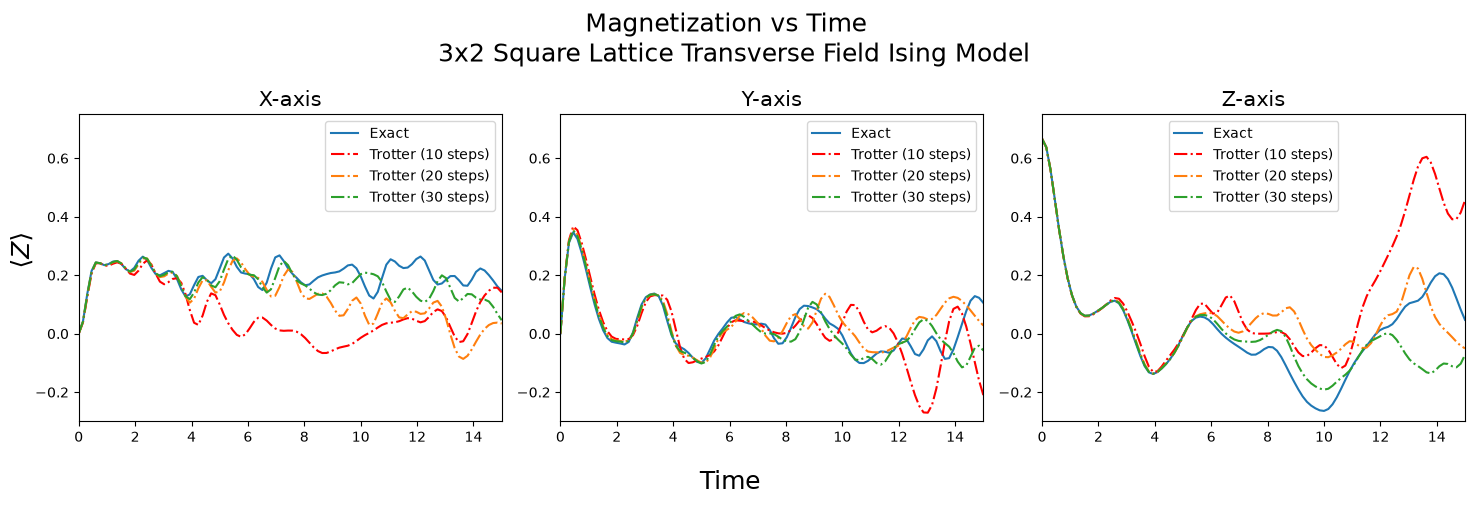

In [21]:
fig, axs = plt.subplots(1, 3, figsize = (15, 5))
ylim = (-0.3, 0.75)

plot_observable(t, magXexact, title = 'X-axis', label = 'Exact', ax = axs[0], ylim = ylim)
plot_observable(t, magXtrot10, linestyle = '-.',  color ='r', label = 'Trotter (10 steps)', ax = axs[0])
plot_observable(t, magXtrot20, linestyle = '-.', label = 'Trotter (20 steps)', ax = axs[0])
plot_observable(t, magXtrot30, linestyle = '-.', label = 'Trotter (30 steps)', ax = axs[0])

plot_observable(t, magYexact, title = 'Y-axis', label = 'Exact', ax = axs[1], ylim = ylim)
plot_observable(t, magYtrot10, linestyle = '-.',  color ='r', label = 'Trotter (10 steps)', ax = axs[1])
plot_observable(t, magYtrot20, linestyle = '-.', label = 'Trotter (20 steps)', ax = axs[1])
plot_observable(t, magYtrot30, linestyle = '-.', label = 'Trotter (30 steps)', ax = axs[1])

plot_observable(t, magZexact, title = 'Z-axis',  label = 'Exact', ax = axs[2], ylim = ylim)
plot_observable(t, magZtrot10, linestyle = '-.',  color ='r', label = 'Trotter (10 steps)', ax = axs[2])
plot_observable(t, magZtrot20, linestyle = '-.', label = 'Trotter (20 steps)', ax = axs[2])
plot_observable(t, magZtrot30, linestyle = '-.', label = 'Trotter (30 steps)', ax = axs[2])

plt.suptitle('Magnetization vs Time \n 3x2 Square Lattice Transverse Field Ising Model', fontsize = 18)
fig.supxlabel('Time', fontsize = 18)
fig.supylabel(r'$\langle Z \rangle$', fontsize = 18)
plt.tight_layout()
plt.show()